In [50]:
import sys
sys.path.append("/home/tg8455/srths/downloaded_code")
from BBSims import noise_calc
#import pymaster as nmt
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from itertools import combinations_with_replacement as cwr
from copy import deepcopy
import astropy.units as u

from dataclasses import dataclass, field
from typing import List, Dict, Optional,Callable


note: this notebook will only be used to make + load our mock, noise-only data; for messiness, figures, and justification for the ell-ranges that we want to use, consult a parallel version of this notebook;

### Raison d'etre: generate one iso_mode at a time, from the 12 possible versions (4 modes x 3 possibilities of R-I correlation)

In [2]:
### science functions:
def make_isocur_params(
    lmax=10_000,
    lensing=True,
    A_s=2.1e-9,
    n_s=0.9665,
    tau_reio=0.056,
    omega_b=0.02237,
    omega_cdm=0.1200,
    h=0.6736,
    # isocurvature controls (for one chosen extra mode; extend as needed)
    iso_mode='cdi',          # 'cdi','bi','nid','niv' or None
    k1= 0.002,
    k2=0.1,
    P_RR_1 = 2.3e-9,
    P_RR_2 = 2.3e-9,
    P_II_1 = 1.0e-11,
    P_II_2 = 1.0e-11,
    #sign of P_RI_1 should indicate whether correlated or anti-correlated
    P_RI_1 = 1.0e-13,
    #always positive
    P_RI_2 = 1.0e-13,
    high_accuracy = False
):

    params = {
        'output': 'tCl,pCl,lCl,mPk',                 # <- include lCl so lensing can be computed
        'lensing': 'yes' if lensing else 'no',
        'l_max_scalars': lmax, 'tau_reio': tau_reio,
        'omega_b': omega_b, 'omega_cdm': omega_cdm, 'h': h,
        'modes': 's',
        'ic': 'ad',
        'P_k_ini type': 'two_scales',
        'k1': k1,
        'k2': k2,
        'P_{RR}^1': P_RR_1,
        'P_{RR}^2': P_RR_2
        # NOTE: intentionally NOT setting 'l_max_lss' to avoid "not read" errors on some builds.
    }

    if iso_mode is not None:
        params['ic'] = f'ad,{iso_mode}'
        params['P_{II}^1'] = P_II_1
        params['P_{II}^2'] = P_II_2
        params['P_{RI}^1'] = P_RI_1
        params['|P_{RI}^2|'] = P_RI_2
        high_accuracy = {
                    'N_ncdm': 1,
                    'm_ncdm': 0.06,
                    'N_ur': 2.0308,
                    'T_cmb': 2.7255,
                    'YHe': 'BBN',
                    'non linear':'hmcode',
                    'hmcode_version': '2020',
                    'recombination': 'HyRec',
                    'lensing':'yes',
                    'output': 'tCl, pCl, lCl, mPk',
                    'modes': 's',
                    'l_max_scalars': 9500,
                    'delta_l_max': 1800,
                    'P_k_max_h/Mpc': 100.0,
                    'l_logstep': 1.025,
                    'l_linstep': 20,
                    'perturbations_sampling_stepsize': 0.05,
                    'l_switch_limber': 30.0,
                    'hyper_sampling_flat': 32.0,
                    'l_max_g': 40,
                    'l_max_ur': 35,
                    'l_max_pol_g': 60,
                    'ur_fluid_approximation': 2,
                    'ur_fluid_trigger_tau_over_tau_k': 130.0,
                    'radiation_streaming_approximation': 2,
                    'radiation_streaming_trigger_tau_over_tau_k': 240.0,
                    'hyper_flat_approximation_nu': 7000.0,
                    'transfer_neglect_delta_k_S_t0': 0.17,
                    'transfer_neglect_delta_k_S_t1': 0.05,
                    'transfer_neglect_delta_k_S_t2': 0.17,
                    'transfer_neglect_delta_k_S_e': 0.17,
                    'accurate_lensing': 1,
                    'start_small_k_at_tau_c_over_tau_h': 0.0004,
                    'start_large_k_at_tau_h_over_tau_k': 0.05,
                    'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
                    'tight_coupling_trigger_tau_c_over_tau_k': 0.008,
                    'start_sources_at_tau_c_over_tau_h': 0.006,
                    'l_max_ncdm': 30,
                    'tol_ncdm_synchronous': 1.0e-06
                    }
    #if high_accuracy:
        #params.update(high_accuracy)

    return params

def compute_cls(
    lmax=10_000,
    lensing=True,
    A_s=2.1e-9,
    n_s=0.9665,
    tau_reio=0.056,
    omega_b=0.02237,
    omega_cdm=0.1200,
    h=0.6736,
    # isocurvature controls (for one chosen extra mode; extend as needed)
    iso_mode='cdi',          # 'cdi','bi','nid','niv' or None
    k1= 0.002,
    k2=0.1,
    P_RR_1 = 2.3e-9,
    P_RR_2 = 2.3e-9,
    P_II_1 = 1.0e-11,
    P_II_2 = 1.0e-11,
    #sign of P_RI_1 should indicate whether correlated or anti-correlated
    P_RI_1 = 1.0e-13,
    #always positive
    P_RI_2 = 1.0e-13,

):
    from classy import Class
    params = make_isocur_params(
        lmax=lmax,
        lensing=lensing,
        A_s=A_s,
        n_s=n_s,
        tau_reio=tau_reio,
        omega_b= omega_b,
        omega_cdm= omega_cdm,
        h= h ,
        # isocurvature controls (for one chosen extra mode; extend as needed)
        iso_mode= iso_mode,          # 'cdi','bi','nid','niv' or None
        k1= k1,
        k2= k2,
        P_RR_1 = P_RR_1,
        P_RR_2 = P_RR_2,
        P_II_1 = P_II_1,
        P_II_2 = P_II_2,
        #sign of P_RI_1 should indicate whether correlated or anti-correlated
        P_RI_1 = P_RI_1,
        #always positive
        P_RI_2 = P_RI_2,
    )
        
    

    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()

    # lensed spectra in K^2 -> convert to μK^2
    cl = cosmo.lensed_cl(lmax)
    ell = cl['ell'][1:]
    TT = cl['tt'][1:] * 1e12
    EE = cl['ee'][1:] * 1e12
    BB = cl['bb'][1:] * 1e12
    TE = cl['te'][1:] * 1e12

    cosmo.struct_cleanup()
    cosmo.empty()
    return {'ell': ell, 'TT': TT, 'EE': EE, 'BB': BB, 'TE': TE}

def knox_auto_cov(c_ell, ell, delta_ell, fsky):
    return 2/(2*ell + 1)/delta_ell /fsky* c_ell**2

def knox_cross_cov(c_cross, c_1, c_2, ell, delta_ell, fsky):
    return 1/(2*ell + 1)/delta_ell /fsky * (c_cross**2 + c_1*c_2)

def make_cross_noise(cell_nz_1,cell_nz_2):
    return np.sqrt(cell_nz_1 * cell_nz_2)

In [3]:
### utils:

def _interp_to(x_new, x_old, y_old):
    return np.interp(x_new, x_old, y_old)

def _apply_cuts(powspec,ells,cuts):
    lmin,lmax = cuts
    new_ell = ells[(ells >= lmin) & (ells <= lmax)]
    new_spec = powspec[(ells >= lmin) & (ells <= lmax)]
    return new_ell,new_spec


### even though some cases have weak theoretical motivations (or rather, they present currently unexplainable departures from LCDM), we consider all possible modes in our forecasts. We cannot rule out a priori the scenario that SO data might perform better on these modes only, and if that ends up being the case, we believe it would be a wasted opportunity to not investigate isocurvature modes at all.

In [121]:
### FLAGS:
ISO_TYPE_ARR = [None,'cdi','nid','niv']
CORR_TYPE_ARR = ['pcor','acor','ucor']
# in the correlated/fully anti-correlated, we consider:
# we vary only P(1)  II  and fix P(2)  II assuming nII = nRR

ISO_TYPE_NOW = None
CORR_TYPE_NOW = 'ucor'

LMAX = 5000

In [5]:
### GLOBAL VARS
SO_FREQ  = [27.0,39.0,93.0, 145.0,225.0,280.0]
SO_CMB_FREQ = [93.0,145.0]
PK_FREQ = [100.0,143.0,217.0,353.0]
PK_CMB_FREQ = [100.0,143.0]

### 1. Making the dict with the power spectra (again, I am working with exactly ONE cosmology).

- I am making a CMB-only SAT likelihood (sacc file of .fits + cov) (with only the 90/150 channels)
- I am making an all-frequencies SAT likelihood

### So there will be one likelihood per sens-mode case. So for the SAT alone, I will have:
    - three folders: ucor, acor, pcor
        NOTE: I MUST MAKE AN ASSUMPTION ABOUT THE FIDUCIAL COSMOLOGY FOR EACH OF THESE. ASSUME 2 TIMES BELOW THE P-ACT LIMIT
    - inside each, ad (as a control),cdi, nid, niv
    - inside each of these the files take the following key:
        sm01/12 etc., lo/lp for LAT mode, y1 for one year.
    

In [6]:
experiment = {}
experiment["label"] = 'SAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['lmax'] = 500

In [7]:
experiment

{'label': 'SAT', 'c_ell_params': {'lmax': 500}}

In [122]:
# generating CMB spectra for the SAT
cmb_theo_dict = {}
if CORR_TYPE_NOW == 'ucor':
    cmb_theo_dict = compute_cls(LMAX, iso_mode = ISO_TYPE_NOW)

In [123]:
# - i will make this inefficient, and then learn how to make it more efficient.
frequencies = {
    "LAT": ["027", "039", "093", "145", "225", "280"],
    "SAT": ["027", "039", "093", "145", "225", "280"],
    "PK": ["100", "143", "217", "353"]
}
SAT_pairs_cmb = ['SAT_093xSAT_093',
                'SAT_145xSAT_145',
                 'SAT_093xSAT_145',
                ]
LAT_pairs_cmb = [s.translate(str.maketrans('S','L')) for s in SAT_pairs_cmb]
                 
LAT_pairs_all = ["LAT_27xLAT_27",
               "LAT_39xLAT_39",
               "LAT_93xLAT_93",
               "LAT_145xLAT_145",
               "LAT_225xLAT_225",
               "LAT_280xLAT_280",
               "LAT_27xLAT_39",
               "LAT_93xLAT_145",
               "LAT_225xLAT_280"]

SAT_pairs_all = [s.translate(str.maketrans('L','S')) for s in LAT_pairs_all]

pk_pairs_cmb = ['PK_100xPK_100', 
                'PK_143xPK_143',
                'PK_100xPK_143']
pk_pairs_all = ["PK_{}xPK_{}".format(*cross) for cross in cwr(frequencies["PK"], 2)]


In [124]:
# generating noise:
def add_case(experiment1,dict_init = None,yrs = 1,sens_mode = 1, f_mode = 0, lmax = 10_000, fsky = 0.1, dell = 10, cuts = [30,300]):
    '''make f_mode negative if there is no such thing in the experiment for LAT
        the function needs to be called any time you want to add a case'''
    new_dict = deepcopy(dict_init)
    if not dict_init:
        new_dict = {}
    if experiment1 == 'SAT':
        key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(experiment1,yrs ,sens_mode,f_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
                        }
    elif experiment1 == 'LAT' or exp_key == 'LAT_pol':
        key = "{}_y{:.0f}_sm{:.0f}".format(experiment1, yrs,sens_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
            }
    return new_dict

In [125]:
cases = {}
for i in np.arange(1,6):
    cases = add_case('SAT',yrs = float(i), dict_init = cases, lmax = 500, dell = 10, cuts = [30,500])
cases = add_case('SAT',yrs = float(10), lmax = 500, dell = 10,dict_init = cases,cuts = [30,500])

In [126]:
cases

{'SAT_y1_sm1fm0': {'yrs': 1.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y2_sm1fm0': {'yrs': 2.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y3_sm1fm0': {'yrs': 3.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y4_sm1fm0': {'yrs': 4.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y5_sm1fm0': {'yrs': 5.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y10_sm1fm0': {'yrs': 10.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]}}

so, the cases dict dictates which experiment we are situated in (we can treat the different sens modes as different experiments; as a reminder, this notebook works for one cosmology)

In [127]:
def make_nz_dict_from_array(nz_array,freq_dict,experiment):
    '''
    noise is for freqxfreq; constructed with 'frequencies' dict in mind
    '''
    nz_dict = {}
    for i,name in enumerate(freq_dict[experiment]):
        if len(name) ==2:
            nz_dict['f0{}'.format(name)] = nz_array[i]
        else:
            nz_dict['f{}'.format(name)] = nz_array[i]
    return nz_dict

In [128]:
# testing the function
case = cases['SAT_y10_sm1fm0']
ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')

In [129]:
# we have the cases, now it is time to generate noises;
# there will be one array of noises per case, which I will add to a dict;
# I should already differentiate between 'pure' and 'cross' spectra, in case the noise 
#estimation I am using is bad
full_noise_dict = deepcopy(cases)
for name in cases.keys():
    case = deepcopy(cases[name])
    ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
    nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')
    full_noise_dict[name]['nz_dict'] = nz_dict
    full_noise_dict[name]['ell_nz'] = ellplot_SA

In [130]:
# IMPORTANT NOTE: in order to make the te covariance, tt and ee need to have the same size (if building from knox).
#after building, the last columns can be struck, according to preference of ell-range!
# 'normal' cov matrices can have non-square TE, but a Gaussian TE cannot, by definition.

lmin_tt = 2
lmax_tt = 2000
lmin_ee = 2
lmax_ee = 2000
dell_tt = 10
dell_ee = 10

ell_pk_tt = np.arange(lmin_tt,lmax_tt, dell_tt)
ell_pk_ee = np.arange(lmin_ee,lmax_ee, dell_ee)

sigma = {"PK_100xPK_100":0.,
        "PK_143xPK_143":0.,
        "PK_217xPK_217":0.,
        "PK_353xPK_353":0.,
        }
sigma_pol = deepcopy(sigma)


# converted temperature noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma["PK_100xPK_100"] = 77.4
sigma["PK_143xPK_143"] = 33.0
sigma["PK_217xPK_217"] = 46.80
sigma["PK_353xPK_353"] = 153.6

# converted polarization noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma_pol["PK_100xPK_100"] = 117.6
sigma_pol["PK_143xPK_143"] = 70.2
sigma_pol["PK_217xPK_217"] = 105.0
sigma_pol["PK_353xPK_353"] = 438.6

ttnz_PK = np.zeros((4,len(ell_pk_tt)))
eenz_PK = np.zeros((4,len(ell_pk_ee)))

for i,f_pair in enumerate(sigma.keys()):
    sigma_rad = np.deg2rad(sigma[f_pair]/ 60) 
    ttnz_PK[i] = ell_pk_tt * 0 + sigma_rad**2
    sigma_pol_rad = np.deg2rad(sigma_pol[f_pair]/ 60)
    eenz_PK[i] = ell_pk_ee * 0 + sigma_pol_rad**2

full_noise_dict['PK'] = { 'lmax':lmax_tt,
                          'dell':dell_tt,
                          'fsky':1.0,
                          'cuts':[lmin_tt,lmax_tt],
                          'nz_dict':  make_nz_dict_from_array( ttnz_PK,frequencies,'PK'),
                          'ell_nz':ell_pk_tt,
                        }
full_noise_dict['PK_pol'] = { 'lmax':lmax_ee,
                              'dell':dell_ee,
                              'fsky':1.0,
                              'cuts':[lmin_ee,lmax_ee],
                              'nz_dict':  make_nz_dict_from_array( eenz_PK,frequencies,'PK'),
                              'ell_nz' : ell_pk_ee,
                                }
full_noise_dict['PK_cross'] = { 'lmax':lmax_ee,
                                'dell':dell_ee,
                                'fsky':1.0,
                                'cuts':[lmin_ee,lmax_ee],
                                'nz_dict': None,
                                'ell_nz' : ell_pk_ee,
                                }

In [131]:
full_noise_dict

{'SAT_y1_sm1fm0': {'yrs': 1.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500],
  'nz_dict': {'f027': array([1.37727902e-01, 2.11209796e-03, 6.84333144e-04, 4.38600704e-04,
          3.75566625e-04, 3.71090024e-04, 3.97980203e-04, 4.50795382e-04,
          5.32306660e-04, 6.50881401e-04, 8.21133231e-04, 1.06655658e-03,
          1.42449662e-03, 1.95478838e-03, 2.75469437e-03, 3.98502635e-03,
          5.91655475e-03, 9.01390592e-03, 1.40899906e-02, 2.25955617e-02,
          3.71724698e-02, 6.27312069e-02, 1.08590799e-01, 1.92813102e-01,
          3.51159109e-01, 6.55974716e-01, 1.25683863e+00, 2.46988053e+00,
          4.97819720e+00, 1.02911630e+01, 2.18197681e+01, 4.74489602e+01,
          1.05825943e+02, 2.42072120e+02, 5.67914744e+02, 1.36648867e+03,
          3.37219283e+03, 8.53495721e+03, 2.21550179e+04, 5.89826126e+04,
          1.61048420e+05, 4.50992154e+05, 1.29527243e+06, 3.81533331e+06,
          1.15261093e+07, 3.57117860e+

### below is the 'grand-unified' noise; will use it independently of the nz_dict implementation

In [132]:
import os
import glob
import numpy as np

from cobaya.likelihoods.base_classes.planck_pliklite import PlanckPlikLite

PLANCK_ROOT  = "/home/tg8455/srths/Planck/lite_2018"

dataset_files = glob.glob(os.path.join(PLANCK_ROOT, "**", "*plik*lite*.dataset"), recursive=True)
print("\n".join(dataset_files[:10]))

dataset = [f for f in dataset_files if "lite" in os.path.basename(f)][0]

like = PlanckPlikLite({"dataset_file": dataset})

cov_lite = like.cov          # nuisance-marginalized covariance (after any cuts)
data_lite = like.X_data      # corresponding data vector entries
print(cov_lite.shape, data_lite.shape)

/home/tg8455/srths/Planck/lite_2018/data/planck_2018_pliklite_native/plik_lite_v22.dataset
(613, 613) (613,)


In [133]:
# below, I'll input tbhe Planck constants: n_bins
nbins_pk = {'TT':215,'TE':199,'EE':199}
cuts_pk = {'TT': [30,2508],'TE': [30,1996],'EE': [30,1996] }
ell_mid = (like.blmin+like.blmax)/2
b_ell = like.blmax[like.blmax<=2508] - like.blmin[like.blmin<=2476]  + 1
print(len(b_ell))
ell_pk ={ 'TT': ell_mid[ell_mid <= 2508], 'TE': ell_mid[ell_mid <= 1996], 'EE': ell_mid[ell_mid <= 1996]}

lite_data = {
    'TT': {
        'c_ell': data_lite[:215],
        'err': np.diag(cov_lite)[:215],
        'ell': ell_pk['TT'],
        'b_ell': b_ell,
    },
    'TE': {
        'c_ell': data_lite[215:414],
        'err': np.diag(cov_lite)[215:414],
        'ell': ell_pk['TE'],
        'b_ell': b_ell[:199],
    },
    'EE': {
        'c_ell': data_lite[414:],
        'err': np.diag(cov_lite)[414:],
        'ell': ell_pk['EE'],
        'b_ell': b_ell[:199]
    },
}
#dell_pk = SEE PK18V


215


In [134]:
'''req_spec is a dict that tells you first what experiments you will want in your likelihood, and for each what spectra and what frequencies.
in the way this is currently set up (which can be subject to change), your full_noise_dict is what sets the tone for the cuts, the binning, etc.'''
req_spec = {}
req_spec['SAT'] = SAT_pairs_cmb
req_spec['PK'] = pk_pairs_cmb
req_spec['PK_pol'] = pk_pairs_cmb
req_spec['PK_cross'] = pk_pairs_cmb

In [135]:
# to create one likelihood, I request the experimental setup from the beginning; so, I need to specify the year that I want, fm,sm, and find that noise;
#it is only required for the SO params, and usually you will want a singular setup, although this is the only thing that makes the mixed likelihoods 
#different from one another

setup = { 'SAT':
    {'yrs' : 1,
        'sens_mode' : 1,
        'f_mode' : 0},
    'LAT':{
        'yrs' : 1,
        'sens_mode' : 1,
    },
          
}

In [136]:
#full_noise_dict

In [137]:
# you have an array with the noise spectra and the params you used to create them for each separate experiment: LAT, SAT, PLanck; 
# it is time to create what will become your likelihood. 
#ideally, you would store just the spectra, and store other metadata separately, if need be

full_lik_data = {'metadata':{}, 
                'data':{},
                }
#input the power spectra that you desire:
for exp_key in req_spec:
    check_cross = False
    if exp_key in setup.keys():
        setup_exp = setup[exp_key]
    
    if exp_key == 'SAT':
        case_key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'
    elif exp_key == 'LAT' :
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['TT']
        cell_type = 'TT'

    elif exp_key == 'LAT_pol' :
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'

    elif exp_key == 'LAT_cross':
        check_cross = True
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['TE']
        cell_type = 'TE'
      
    elif exp_key == 'PK' :
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['TT']
        cell_type = 'TT'

    
    elif exp_key == 'PK_pol' :
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'

        
    elif exp_key == 'PK_cross':
        check_cross = True
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['TE']
        cell_type = 'TE'

    pairs_current = req_spec[exp_key]
    if not check_cross:
        nz_dict = deepcopy(full_noise_dict[case_key]['nz_dict'])
    else:
        nz_dict = {}

    meta = deepcopy(full_noise_dict[case_key])
    meta.pop('nz_dict')
    meta.pop('ell_nz')
    full_lik_data['metadata'][exp_key] = meta
    full_lik_data['metadata'][exp_key]['cell_type'] = cell_type
    full_lik_data['data'][exp_key] = {}
    for spec_key in pairs_current:

        left, right = spec_key.split('x')
        f1 = left.split('_')[-1]
        f2 = right.split('_')[-1]
        #print("f1: {}, f2: {}".format(f1,f2))
        
        ell_new = full_noise_dict[case_key]['ell_nz']
        ell_old = cmb_theo_dict['ell']
        cuts = full_noise_dict[case_key]['cuts']
        ell_old_cut, cell_cmb_cut = _apply_cuts(c_ell_theo, cmb_theo_dict['ell'], cuts)
        #print(ell_new)
        cell_cmb_cut = _interp_to(ell_new, ell_old_cut,cell_cmb_cut)
        ell_new_cut, cell_cmb_cut = _apply_cuts(cell_cmb_cut, ell_new, cuts)
        if not check_cross:
            if f1 == f2:
                nz_arr = nz_dict['f{}'.format(f1)]
                _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
            else:
                nz_arr = make_cross_noise(nz_dict['f{}'.format(f1)],nz_dict['f{}'.format(f2)])
                _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
        else:
            nz_arr_cut = cell_cmb_cut*0
        cell_mock = cell_cmb_cut + nz_arr_cut
        full_lik_data['data'][exp_key][spec_key] = {'c_ell' : cell_mock, 'ell': ell_new_cut}


print(full_lik_data)    

{'metadata': {'SAT': {'yrs': 1.0, 'sens_mode': 1, 'f_mode': 0, 'fsky': 0.1, 'lmax': 500, 'dell': 10, 'cuts': [30, 500], 'cell_type': 'EE'}, 'PK': {'lmax': 2000, 'dell': 10, 'fsky': 1.0, 'cuts': [2, 2000], 'cell_type': 'TT'}, 'PK_pol': {'lmax': 2000, 'dell': 10, 'fsky': 1.0, 'cuts': [2, 2000], 'cell_type': 'EE'}, 'PK_cross': {'lmax': 2000, 'dell': 10, 'fsky': 1.0, 'cuts': [2, 2000], 'cell_type': 'TE'}}, 'data': {'SAT': {'SAT_093xSAT_093': {'c_ell': array([2.59283210e-05, 3.44590409e-05, 4.37592905e-05, 5.23987678e-05,
       5.95552121e-05, 6.46788342e-05, 6.74929449e-05, 6.79237467e-05,
       6.60749419e-05, 6.22145574e-05, 5.67345849e-05, 5.01250933e-05,
       4.29326317e-05, 3.57273776e-05, 2.90670934e-05, 2.34710770e-05,
       1.93795222e-05, 1.71595390e-05, 1.70387626e-05, 1.91784149e-05,
       2.35490352e-05, 3.00679271e-05, 3.85202769e-05, 4.85591897e-05,
       5.98238233e-05, 7.18655109e-05, 8.41840049e-05, 9.62816187e-05,
       1.07701482e-04, 1.18018397e-04, 1.26808890e-

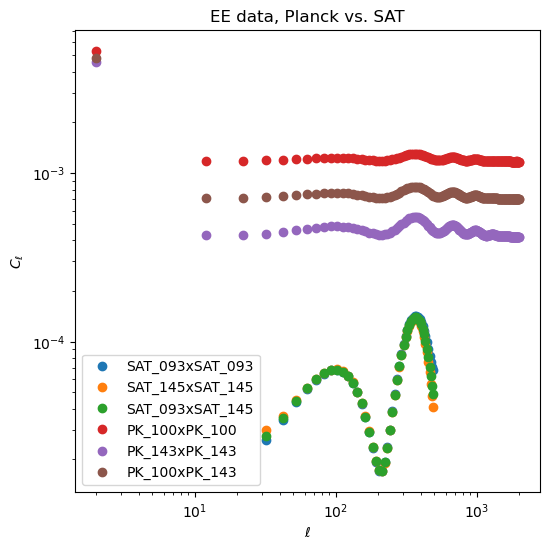

In [138]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['SAT']:
    curr_dict = full_lik_data['data']['SAT'][name]
    ax.loglog(curr_dict['ell'],curr_dict['c_ell'] , marker = 'o', label = name, linestyle = 'None')
    ax.legend()
for name in full_lik_data['data']['PK_pol']:
    curr_dict = full_lik_data['data']['PK_pol'][name]
    ax.loglog(curr_dict['ell'],curr_dict['c_ell'] , marker = 'o', label = name, linestyle = 'None')
    ax.set_title('EE data, Planck vs. SAT')
    ax.set_ylabel(r'$C_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

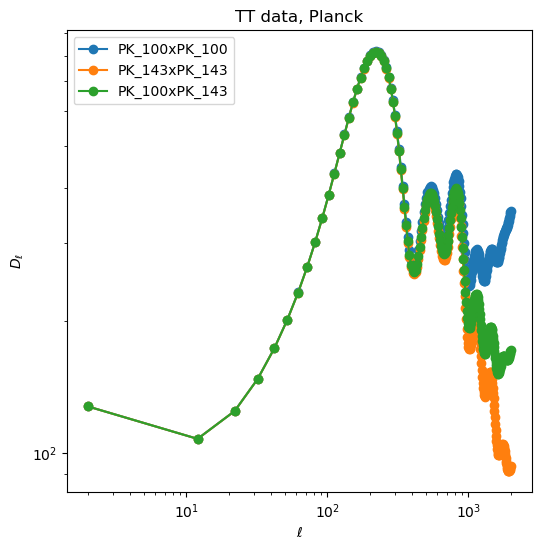

In [139]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['PK']:
    curr_dict = full_lik_data['data']['PK'][name]
    ell_plot = curr_dict['ell']
    pref = ell_plot*(ell_plot+1)/(2*np.pi)
    ax.loglog(ell_plot,pref*curr_dict['c_ell'] , marker = 'o', label = name)
    ax.set_title('TT data, Planck')
    ax.set_ylabel(r'$D_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

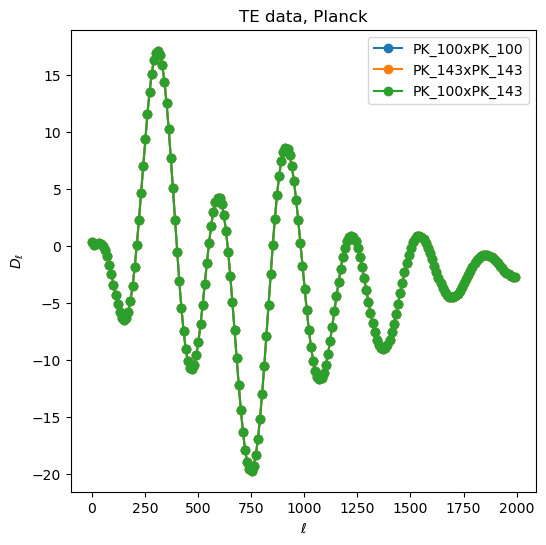

In [140]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['PK_cross']:
    curr_dict = full_lik_data['data']['PK_cross'][name]
    ell_plot = curr_dict['ell']
    pref = ell_plot*(ell_plot+1)/(2*np.pi)
    ax.plot(ell_plot,pref*curr_dict['c_ell'] , marker = 'o', label = name)
    ax.set_title('TE data, Planck')
    ax.set_ylabel(r'$D_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

In [141]:
def build_full_lik_cov(full_lik_data, setup, cases,
                       knox_auto_cov, knox_cross_cov):

    auto_blocks = {'SAT', 'LAT', 'LAT_pol', 'PK', 'PK_pol'}
    cross_block_map = {
        'LAT_cross': ('LAT', 'LAT_pol'),
        'PK_cross': ('PK', 'PK_pol'),
    }


    full_lik_cov = {'metadata': deepcopy(full_lik_data['metadata']),
                    'data':{}}

    for exp_key, spec_dict in full_lik_data['data'].items():
        dell_curr, fsky_curr = full_lik_data['metadata'][exp_key]['dell'],full_lik_data['metadata'][exp_key]['fsky']

        full_lik_cov['data'][exp_key] = {}

        if exp_key in auto_blocks:
            for spec_key, spec_info in spec_dict.items():
                c_ell = np.asarray(spec_info['c_ell'])
                ell = np.asarray(spec_info['ell'])

                cov = knox_auto_cov(
                    c_ell=c_ell,
                    ell=ell,
                    delta_ell=dell_curr,
                    fsky=fsky_curr
                )

                full_lik_cov['data'][exp_key][spec_key] = {
                    'cov': cov,
                    'ell': ell
                }


        elif exp_key in cross_block_map:
            tt_block, ee_block = cross_block_map[exp_key]

            if tt_block in full_lik_data['data'] and ee_block in full_lik_data['data']:
                for spec_key, spec_info in spec_dict.items():
                    if spec_key in full_lik_data['data'][tt_block] and spec_key in full_lik_data['data'][ee_block]:
                        c_cross = np.asarray(spec_info['c_ell'])
                        ell_cross = np.asarray(spec_info['ell'])

                        c_1 = np.asarray(full_lik_data['data'][tt_block][spec_key]['c_ell'])
                        c_2 = np.asarray(full_lik_data['data'][ee_block][spec_key]['c_ell'])

                        cov = knox_cross_cov(
                            c_cross=c_cross,
                            c_1=c_1,
                            c_2=c_2,
                            ell=ell_cross,
                            delta_ell=dell_curr,
                            fsky=fsky_curr
                        )

                        full_lik_cov['data'][exp_key][spec_key] = {
                            'cov': cov,
                            'ell': ell_cross
                        }

    return full_lik_cov

In [142]:
full_lik_cov = build_full_lik_cov(full_lik_data, setup, cases,knox_auto_cov, knox_cross_cov)

In [143]:
full_lik_cov

{'metadata': {'SAT': {'yrs': 1.0,
   'sens_mode': 1,
   'f_mode': 0,
   'fsky': 0.1,
   'lmax': 500,
   'dell': 10,
   'cuts': [30, 500],
   'cell_type': 'EE'},
  'PK': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'TT'},
  'PK_pol': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'EE'},
  'PK_cross': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'TE'}},
 'data': {'SAT': {'SAT_093xSAT_093': {'cov': array([2.06854717e-11, 2.79394235e-11, 3.64738191e-11, 4.39300938e-11,
           4.89217005e-11, 5.07072921e-11, 4.92464606e-11, 4.50110767e-11,
           3.88079817e-11, 3.15971523e-11, 2.42929292e-11, 1.76317543e-11,
           1.20866286e-11, 7.85504927e-12, 4.89794737e-12, 3.01858332e-12,
           1.95099159e-12, 1.45407298e-12, 1.36620908e-12, 1.65308583e-12,
           2.38519165e-12, 3.72816594e-12, 5.87648210e-12, 8.98283772e-12,
           1.31335407e-11, 1.82819528e-1

### Recreating Fig. 12 of ACT DR6 Spectra Paper

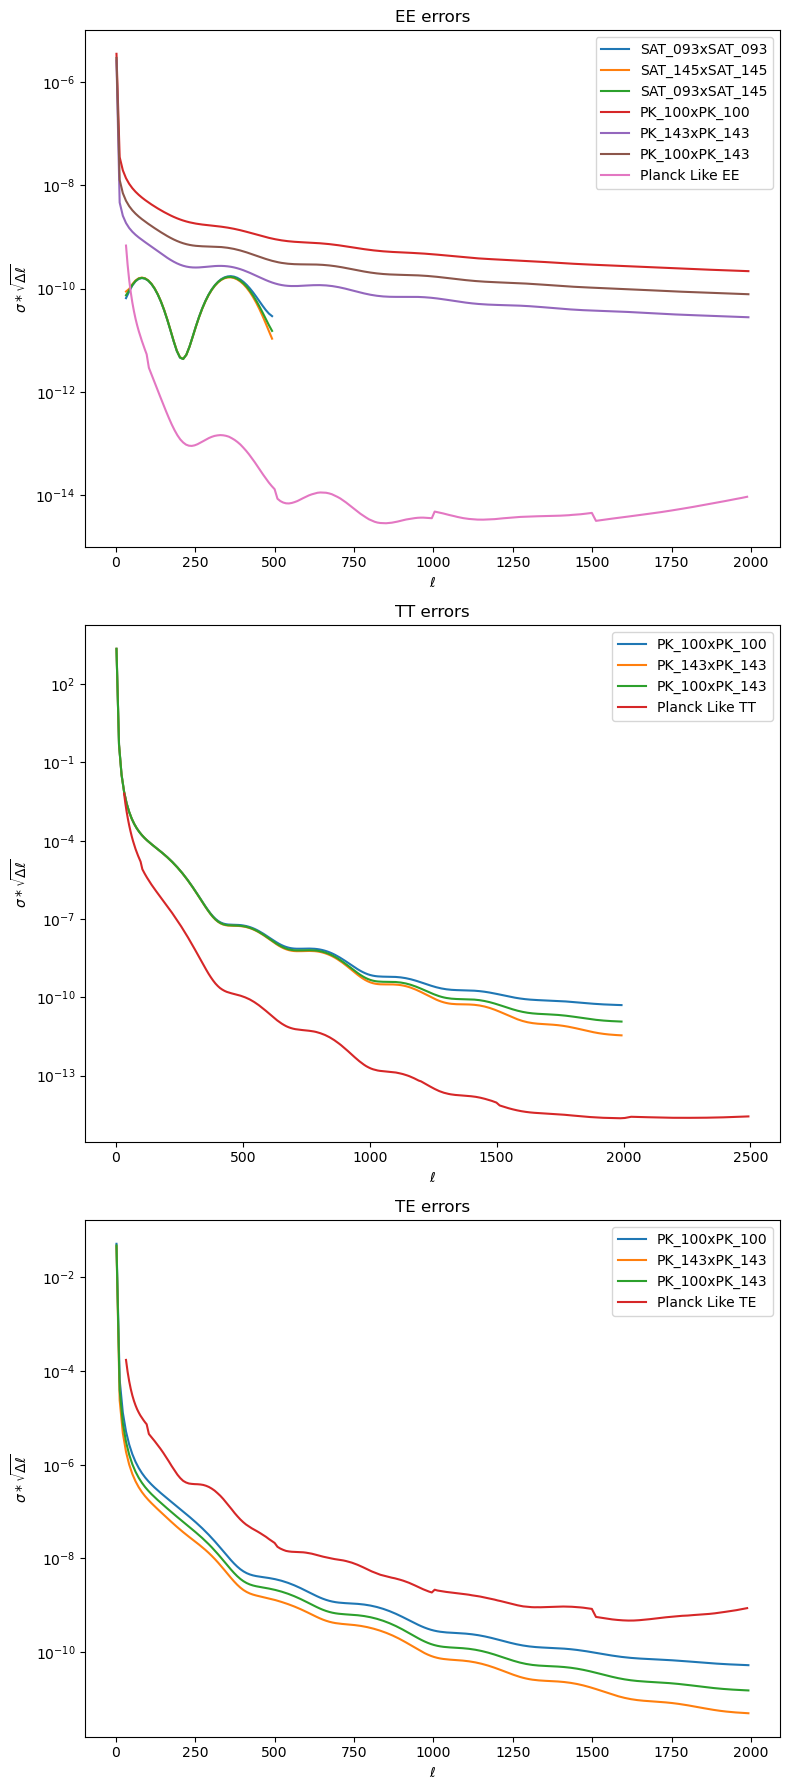

In [144]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

### EE Spectra Comparison

ax = axes[0]

exp_key = 'SAT'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

exp_key = 'PK_pol'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'EE'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']*(2*np.pi)/(ell_plot*(ell_plot+1))
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


### TT Spectra Comparison
ax = axes[1]

exp_key = 'PK'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'TT'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']*(2*np.pi)/(ell_plot*(ell_plot+1))
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


### TE Spectra Comparison 

ax = axes[2]

exp_key = 'PK_cross'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'TE'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


plt.tight_layout()
plt.savefig('planck_err_comp.png', dpi=300, bbox_inches='tight')
plt.show()

- plot C_ell vs. N_ell
- look at Planck noise curves

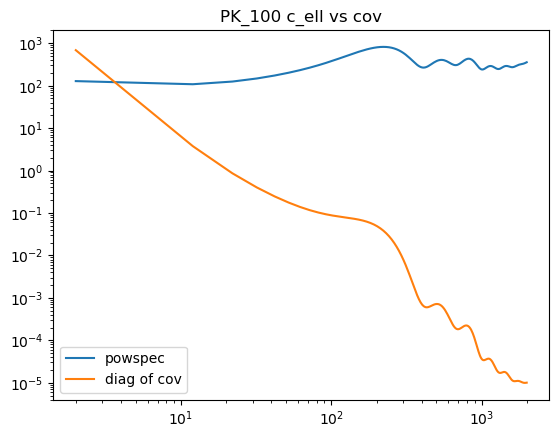

In [145]:
tt_100 = full_lik_data["data"]["PK"]['PK_100xPK_100']["c_ell"]
cov_100 = full_lik_cov["data"]["PK"]['PK_100xPK_100']["cov"]
ell_100 = full_lik_cov["data"]["PK"]['PK_100xPK_100']["ell"]
pref = ell_100*(ell_100 +1)/2/np.pi

plt.loglog(ell_100,pref*tt_100, label = 'powspec')
plt.loglog(ell_100,pref*cov_100, label = 'diag of cov')
plt.title("PK_100 c_ell vs cov")
plt.legend()

### game time for Fisher !

In [146]:
### so, right now I am running with Susanna's choice of parameters. In the near future, I will do a convergence study, and optimize for it.

### rationale for Fisher:
- func takes in full_lik_cov + specification of which exp_key (= experiment key) I want in the covariance
      - smaller func makes the cov by just stringing things together (make np.diag and stack if length of element in cov_ask = 3, which indicates TT, TE EE covariance, and cov is stacked as [[TT,TE],[TE,EE]], where each denotes a diagonal matrix; if only one experiment is requested, then just put all the spectra in one array and do np.diag.)
  
- find the type in the metadata (full_lik_data['metadata'][exp_key]['cell_type']; options: 'TT','TE', 'EE')

- make dcls (use central diff, then stack just like cov)

- run the fisher algo, which is just an implementation of:
          $F_{ij} = \sum_ell (2\ell+1)*fsky*Tr(C_\ell^-1 \frac{\partial C}{\partial \theta_i}C_\ell^-1 \frac{\partial C}{\partial \theta_j})

In [147]:
@dataclass
class SpectrumBand:
    """
    One (experiment, frequency-pair, spectrum-type) data stream, 
    trimmed to the configured ell cuts.

    Attributes
    ----------
    exp_key   : which experiment block this came from
    channel   : frequency-pair key, e.g. 'SAT_093xSAT_093'
    cell_type : 'TT', 'EE', or 'TE'
    ell       : bin-centre multipoles after cuts,  shape (n_ell,)
    dell      : bin width Δℓ  (scalar, from metadata)
    fsky      : sky fraction   (scalar, from metadata)
    cov       : diagonal of the Gaussian power-spectrum covariance,
                shape (n_ell,).  Each entry is Var(Ĉ^XY_ℓ) at that bin.
    """
    exp_key:   str
    channel:   str
    cell_type: str
    ell:       np.ndarray
    dell:      int
    fsky:      float
    cov:       np.ndarray


def parse_spectrum_bands(full_lik_cov, exp_keys) -> list[SpectrumBand]:
    """
    Parse every requested experiment into a flat list of SpectrumBand objects.

    Parameters
    ----------
    full_lik_cov : dict
        The input dictionary (metadata + data).
    exp_keys : str or list[str]
        Experiment keys to include, e.g. ['SAT', 'PK', 'PK_pol', 'PK_cross'].

    Returns
    -------
    list[SpectrumBand]
        One entry per (exp_key × channel_pair), ell-trimmed to configured cuts.
    """
    if isinstance(exp_keys, str):
        exp_keys = [exp_keys]

    bands = []
    for exp_key in exp_keys:
        meta          = full_lik_cov["metadata"][exp_key]
        cell_type     = meta["cell_type"]
        fsky          = meta["fsky"]
        dell          = meta["dell"]
        lmin, lmax    = meta["cuts"]

        for channel, ch_dict in full_lik_cov["data"][exp_key].items():
            ell  = np.asarray(ch_dict["ell"], dtype=int)
            cov  = np.asarray(ch_dict["cov"], dtype=float)
            mask = (ell >= lmin) & (ell <= lmax)

            bands.append(SpectrumBand(
                exp_key   = exp_key,
                channel   = channel,
                cell_type = cell_type,
                ell       = ell[mask],
                dell      = dell,
                fsky      = fsky,
                cov       = cov[mask],
            ))

    return bands



def eval_cls_on_bands(bands: list[SpectrumBand], raw_cls: dict) -> list[np.ndarray]:
    """
    Sample theory Cls at each band's ell grid.

    Parameters
    ----------
    bands   : list[SpectrumBand]  (from parse_spectrum_bands)
    raw_cls : dict  {cell_type: array indexed by integer ell}

    Returns
    -------
    list of (n_ell,) arrays, one per band
    """
    return [np.asarray(raw_cls[b.cell_type])[b.ell] for b in bands]


def central_diff_on_bands(
    theta0:      dict,
    param:       str,
    step:        float,
    bands:       list[SpectrumBand],
    compute_cls: callable,
    ell_max:     int = 10_000,
) -> list[np.ndarray]:
    """
    Central-difference derivative  dC_ell / d(param)  for every band.

    Parameters
    ----------
    theta0      : fiducial parameter dict
    param       : parameter name to differentiate
    step        : step size in parameter units
    bands       : list[SpectrumBand]
    compute_cls : callable(**theta, lmax=int) -> {cell_type: Cl_array}
    ell_max     : maximum ell passed to the Cl calculator

    Returns
    -------
    list of (n_ell,) arrays  dC/dparam  at each band's ell grid
    """
    theta_hi = {**theta0, param: theta0[param] + step}
    theta_lo = {**theta0, param: theta0[param] - step}

    cls_hi = compute_cls(**theta_hi, lmax=ell_max)
    cls_lo = compute_cls(**theta_lo, lmax=ell_max)

    return [
        (np.asarray(cls_hi[b.cell_type])[b.ell]
         - np.asarray(cls_lo[b.cell_type])[b.ell]) / (2.0 * step)
        for b in bands
    ]

In [148]:
@dataclass
class FisherResult:
    F:          np.ndarray
    Cov_params: np.ndarray
    sigma:      np.ndarray
    dC:         list
    bands:      list
    param_list: list[str]

    # ── prior / combination (as before) ──────────────────────────────────────

    def with_prior(self, priors: dict[str, float]) -> "FisherResult":
        unknown = set(priors) - set(self.param_list)
        if unknown:
            raise KeyError(f"Prior specified for unknown parameters: {unknown}")
        F_prior = self.F.copy()
        for param, sigma_prior in priors.items():
            i = self.param_list.index(param)
            F_prior[i, i] += 1.0 / sigma_prior**2
        Cov_prior = np.linalg.pinv(F_prior)
        return FisherResult(
            F=F_prior, Cov_params=Cov_prior,
            sigma=np.sqrt(np.diag(Cov_prior)),
            dC=self.dC, bands=self.bands, param_list=self.param_list,
        )

    def combine(self, other: "FisherResult") -> "FisherResult":
        if self.param_list != other.param_list:
            raise ValueError("param_lists must match to combine.")
        F_combined = self.F + other.F
        Cov_combined = np.linalg.pinv(F_combined)
        return FisherResult(
            F=F_combined, Cov_params=Cov_combined,
            sigma=np.sqrt(np.diag(Cov_combined)),
            dC=self.dC + other.dC,
            bands=self.bands + other.bands,
            param_list=self.param_list,
        )

    # ── internal helpers ─────────────────────────────────────────────────────

    def _centers(self, scaled_params: set = frozenset()) -> np.ndarray:
        """Fiducial values in display/differentiation space (scaled where needed)."""
        return np.array(
            [1e10 * self._theta0[p] if p in scaled_params else self._theta0[p]
             for p in self.param_list],
            dtype=float,
        )

    def _correlation_matrix(self) -> np.ndarray:
        den  = np.outer(self.sigma, self.sigma)
        Corr = np.divide(self.Cov_params, den,
                         out=np.zeros_like(self.Cov_params), where=den > 0)
        np.fill_diagonal(Corr, 1.0)
        return Corr

    def _latex_labels(self, label_map: dict[str, str]) -> list[str]:
        return [label_map.get(p, p) for p in self.param_list]

    # ── public analysis methods ───────────────────────────────────────────────

    def summary_table(
        self,
        theta0:        dict,
        scaled_params: set = frozenset(),
    ) -> "pd.DataFrame":
        """
        Return a DataFrame with columns Fiducial / sigma / S·N⁻¹.
        Rows indexed by param_list; scaled params shown in ×1e10 space.
        """
        import pandas as pd
        centers = np.array(
            [1e10 * theta0[p] if p in scaled_params else theta0[p]
             for p in self.param_list],
            dtype=float,
        )
        return pd.DataFrame(
            {
                "Fiducial": centers,
                "sigma":    self.sigma,
                "S/N":      np.divide(
                    centers, self.sigma,
                    out=np.full_like(centers, np.nan),
                    where=self.sigma > 0,
                ),
            },
            index=self.param_list,
        )

    def plot_correlation(
        self,
        exp_name:  str  = "",
        save_path: str  = None,
        ax=None,
    ):
        """Heatmap of the parameter correlation matrix."""
        import matplotlib.pyplot as plt
        Corr = self._correlation_matrix()
        n    = len(self.param_list)

        if ax is None:
            fig, ax = plt.subplots(figsize=(0.7 * n + 3, 0.7 * n + 3))
        else:
            fig = ax.figure

        im = ax.imshow(Corr, vmin=-1, vmax=1)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(self.param_list, rotation=45, ha="right")
        ax.set_yticklabels(self.param_list)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
        ax.set_title(f"Correlation matrix {exp_name}")
        fig.tight_layout()

        if save_path is not None:
            fig.savefig(save_path)
        return fig, ax

    def plot_triangle(
        self,
        theta0:        dict,
        label_map:     dict[str, str] = None,
        scaled_params: set            = frozenset(),
        exp_name:      str            = "",
        save_path:     str            = None,
    ):
        """GetDist triangle plot centred on theta0."""
        from getdist.gaussian_mixtures import GaussianND
        from getdist import plots
        import matplotlib.pyplot as plt

        label_map  = label_map or {}
        centers    = np.array(
            [1e10 * theta0[p] if p in scaled_params else theta0[p]
             for p in self.param_list],
            dtype=float,
        )
        labels = [label_map.get(p, p) for p in self.param_list]

        gauss = GaussianND(centers, self.Cov_params,
                           names=self.param_list, labels=labels)
        g = plots.get_subplot_plotter()
        g.triangle_plot([gauss], self.param_list, filled=True)
        plt.suptitle(f"{exp_name} Fisher")

        if save_path is not None:
            plt.savefig(save_path)
        return g

    def save_summary_table(
    self,
    theta0:        dict,
    scaled_params: set  = frozenset(),
    exp_name:      str  = "",
    title:         str  = None,
    save_path:     str  = None,
    ):
        df  = self.summary_table(theta0, scaled_params)
        fig, ax = plt.subplots(figsize=(8, 0.6 * len(df) + 1))
        ax.axis("off")
        table = ax.table(
            cellText=np.round(df.values, 4),
            colLabels=df.columns,
            rowLabels=df.index,
            loc="center",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)
    
        if title is not None:
            fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    
        fig.tight_layout()
        path = save_path or f"fisher_summary_{exp_name}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        plt.close(fig)
        return df

In [149]:
def _step_for(param: str, steps: dict, scaled_params: set) -> tuple[float, bool]:
    """
    Return (step_size_in_differentiation_space, is_scaled).

    For scaled params the step is in the ×1e10 space; raw step is stored in `steps`.
    """
    if param not in steps:
        raise KeyError(f"No step size provided for parameter '{param}'")
    return steps[param], (param in scaled_params)


def _perturb(theta0: dict, param: str, delta: float, scaled_params: set) -> dict:
    """Return a copy of theta0 with one parameter perturbed by delta."""
    th = dict(theta0)
    if param in scaled_params:
        th[param] = (1e10 * theta0[param] + delta) * 1e-10
    else:
        th[param] = theta0[param] + delta
    return th


def compute_dC_bands(
    theta0:        dict,
    param:         str,
    step:          float,
    bands:         list,           # list[SpectrumBand]
    compute_cls:   Callable,
    scaled_params: set  = frozenset(),
    ell_max:       int  = 10_000,
) -> list:
    """
    Central-difference dC_ℓ/d(param) for every band.

    Returns
    -------
    list of (n_ell_b,) arrays, one per band
    """
    theta_hi = _perturb(theta0, param, +step, scaled_params)
    theta_lo = _perturb(theta0, param, -step, scaled_params)

    cls_hi = compute_cls(**theta_hi, lmax=ell_max)
    cls_lo = compute_cls(**theta_lo, lmax=ell_max)

    return [
        (np.asarray(cls_hi[b.cell_type])[b.ell]
         - np.asarray(cls_lo[b.cell_type])[b.ell]) / (2.0 * step)
        for b in bands
    ]

def fisher_forecast(
    theta0:        dict,
    param_list:    list[str],
    bands:         list,           # list[SpectrumBand]  (from parse_spectrum_bands
                                   # OR any external source with .ell, .cov, .cell_type)
    compute_cls:   Callable,
    steps:         dict,           # {param: step_size}  in differentiation space
    scaled_params: set   = frozenset(),
    ell_max:       int   = 10_000,
    use_pinv:      bool  = False,
) -> FisherResult:
    """
    Compute the Fisher matrix via the diagonal Gaussian covariance formula:

        F_αβ = Σ_{bands} Σ_ℓ  (dC_α[ℓ] · dC_β[ℓ]) / Var(Ĉ_ℓ)

    where band.cov already encodes  Var(Ĉ_ℓ) = 2C_ℓ²/[(2ℓ+1)Δℓ f_sky],
    so no additional (2ℓ+1) / f_sky weighting is applied here.

    Parameters
    ----------
    theta0        : fiducial parameter dict
    param_list    : parameters to forecast, defines row/column ordering of F
    bands         : iterable of objects with  .cell_type, .ell, .cov  attributes
                    Can be SpectrumBand objects from parse_spectrum_bands(), or
                    any external covariance source (Planck_Lite, etc.) as long as
                    it exposes the same interface.
    compute_cls   : callable(**theta, lmax=int) -> {cell_type: Cl_array}
    steps         : step sizes, keyed by param name
    scaled_params : params whose fiducial values are multiplied by 1e10 before
                    differencing (e.g. primordial power spectrum amplitudes)
    ell_max       : passed to compute_cls
    use_pinv      : use pseudo-inverse instead of inv when inverting F

    Returns
    -------
    FisherResult
    """
    # ── 1. Derivatives ───────────────────────────────────────────────────────
    dC = []
    for param in param_list:
        step, is_scaled = _step_for(param, steps, scaled_params)
        dC_p = compute_dC_bands(
            theta0        = theta0,
            param         = param,
            step          = step,
            bands         = bands,
            compute_cls   = compute_cls,
            scaled_params = scaled_params,
            ell_max       = ell_max,
        )
        dC.append(dC_p)   # dC[i][b] has shape (n_ell_b,)

    # ── 2. Fisher matrix ─────────────────────────────────────────────────────
    # band.cov is Var(Ĉ_ℓ), so the weight is simply 1/Var.
    # Summing over all bands and all ell bins within each band.
    npar = len(param_list)
    F = np.zeros((npar, npar), dtype=float)

    for i in range(npar):
        for j in range(i, npar):
            s = sum(
                np.sum(dC[i][b] * dC[j][b] / band.cov)
                for b, band in enumerate(bands)
            )
            F[i, j] = s
            F[j, i] = s

    # ── 3. Parameter covariance ──────────────────────────────────────────────
    inv = np.linalg.pinv if use_pinv else np.linalg.inv
    Cov_params = inv(F)
    sigma      = np.sqrt(np.diag(Cov_params))

    return FisherResult(
        F          = F,
        Cov_params = Cov_params,
        sigma      = sigma,
        dC         = dC,
        bands      = list(bands),
        param_list = list(param_list),
    )


In [150]:
SCALED10_PARAMS = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

param_list = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"
]

steps_abs = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}

steps_scaled10 = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
    "P_II_1": 0.05,
    "P_II_2": 0.05,
}

theta0 = {
    "omega_b": 0.02237,
    "omega_cdm": 0.11933,
    "h": 0.6766,
    "tau_reio": 0.0561,
    "P_RR_1": 2.3e-9,
    "P_RR_2": 2.3e-9,
    "P_II_1": 1.0e-9,
    "P_II_2": 1.0e-9,
}


bands_planck = parse_spectrum_bands(full_lik_cov, ["PK", "PK_cross", "PK_pol"])

result_planck = fisher_forecast(
    theta0        = theta0,
    param_list    = param_list,
    bands         = bands_planck,
    compute_cls   = compute_cls,
    steps         = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max       = 10_000,
)

print(result_planck.sigma)

[8.05950339e-05 8.23821979e-04 3.65909225e-03 3.63731466e-03
 2.77710967e-01 1.64904004e-01 4.03700678e-01 1.40346912e+00]


In [151]:
bands_sat = parse_spectrum_bands(full_lik_cov, ["SAT"])

result_sat = fisher_forecast(
    theta0        = theta0,
    param_list    = param_list,
    bands         = bands_sat,
    compute_cls   = compute_cls,
    steps         = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max       = 10_000,
)

result_combined = result_planck.combine(result_sat)

In [152]:
ratio = result_combined.sigma/result_planck.sigma
for i, name in enumerate(param_list):
    print(f"{name}: {np.round(ratio[i],3)}")

omega_b: 0.99
omega_cdm: 0.934
h: 0.946
tau_reio: 0.984
P_RR_1: 0.963
P_RR_2: 0.987
P_II_1: 0.986
P_II_2: 0.673


In [153]:
def plot_save_suite(result, EXP_NAME,
                   LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                            "P_II_1":    r"10^{10}P_{II,1}",
                            "P_II_2":    r"10^{10}P_{II,2}",
                        },
                   ):
    table_savepath = "images/032226_fisher/sum_table_{}.png".format(EXP_NAME)
    corrmat_savepath = "images/032226_fisher/corr_matrix_{}.png".format(EXP_NAME)
    triangle_savepath = "images/032226_fisher/triangle_plot_{}.png".format(EXP_NAME)
    
    result_now = deepcopy(result)
    
    df = result_now.save_summary_table(
        theta0=theta0, scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=table_savepath,
    )
    display(df)
    
    result_now.plot_correlation(exp_name=EXP_NAME, save_path=corrmat_savepath)
    
    result_now.plot_triangle(
        theta0=theta0, label_map=LATEX,
        scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=triangle_savepath,
    )


,Fiducial,sigma,S/N
omega_b,0.02237,0.000081,277.560526
omega_cdm,0.11933,0.000824,144.849255
h,0.67660,0.003659,184.909249
tau_reio,0.05610,0.003637,15.423466
P_RR_1,23.00000,0.277711,82.819920
P_RR_2,23.00000,0.164904,139.475085
P_II_1,10.00000,0.403701,24.770828
P_II_2,10.00000,1.403469,7.125201


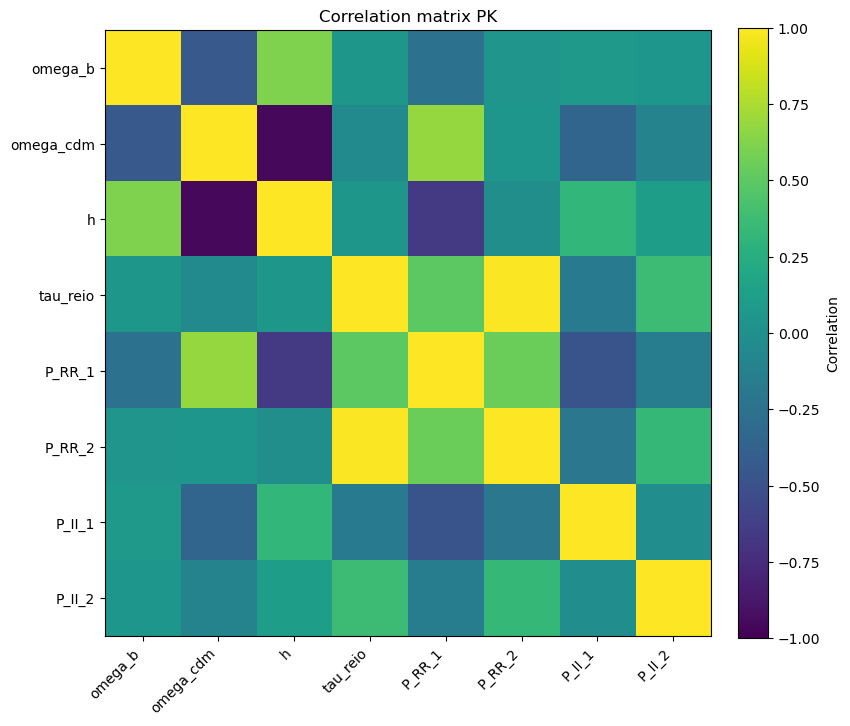

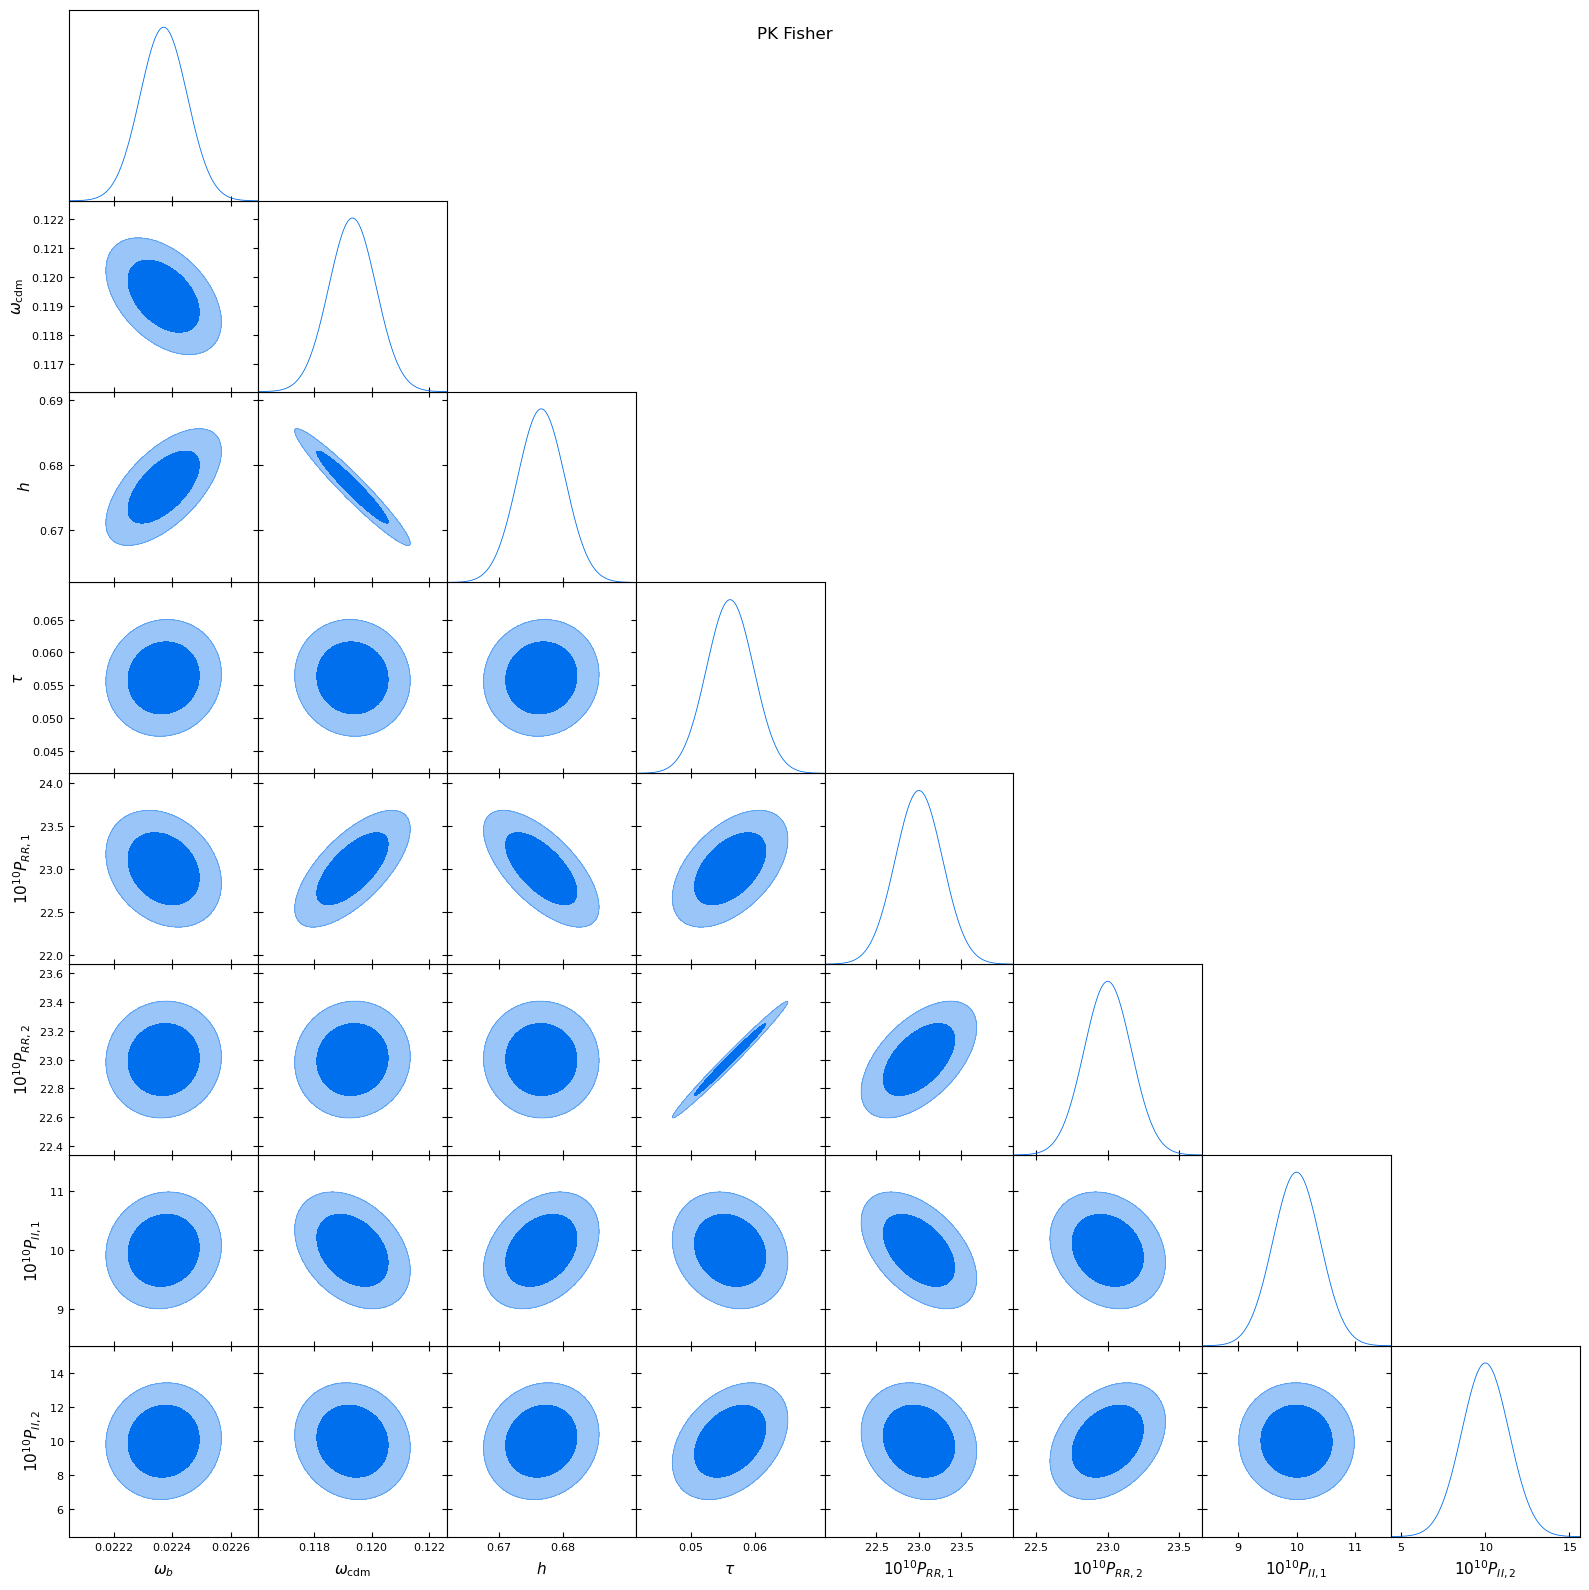

In [154]:
plot_save_suite(result_planck,'PK')

,Fiducial,sigma,S/N
omega_b,0.02237,0.000080,280.300892
omega_cdm,0.11933,0.000769,155.161068
h,0.67660,0.003461,195.489119
tau_reio,0.05610,0.003578,15.679156
P_RR_1,23.00000,0.267323,86.038200
P_RR_2,23.00000,0.162759,141.312928
P_II_1,10.00000,0.398147,25.116322
P_II_2,10.00000,0.944060,10.592542


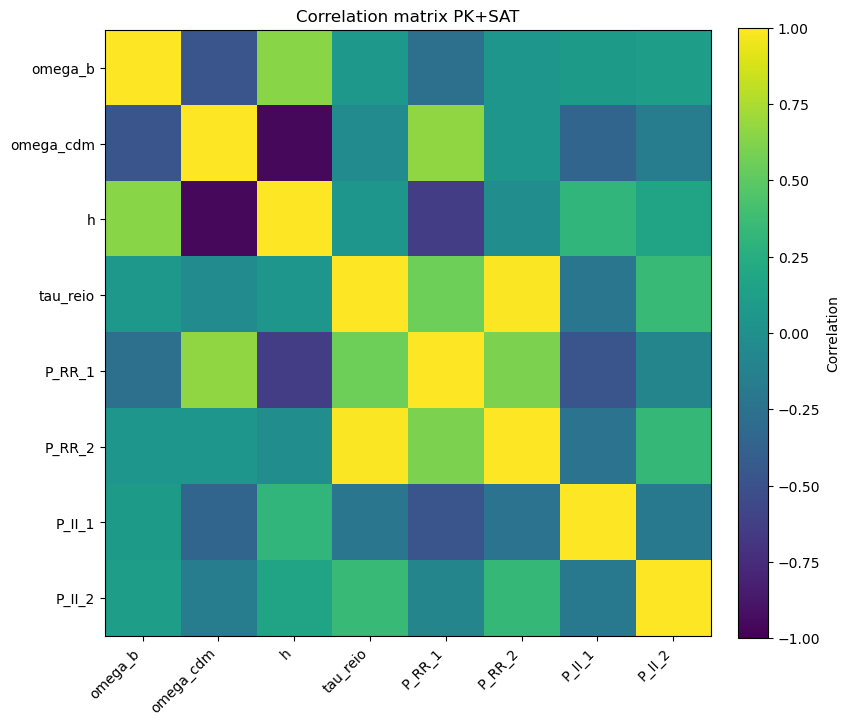

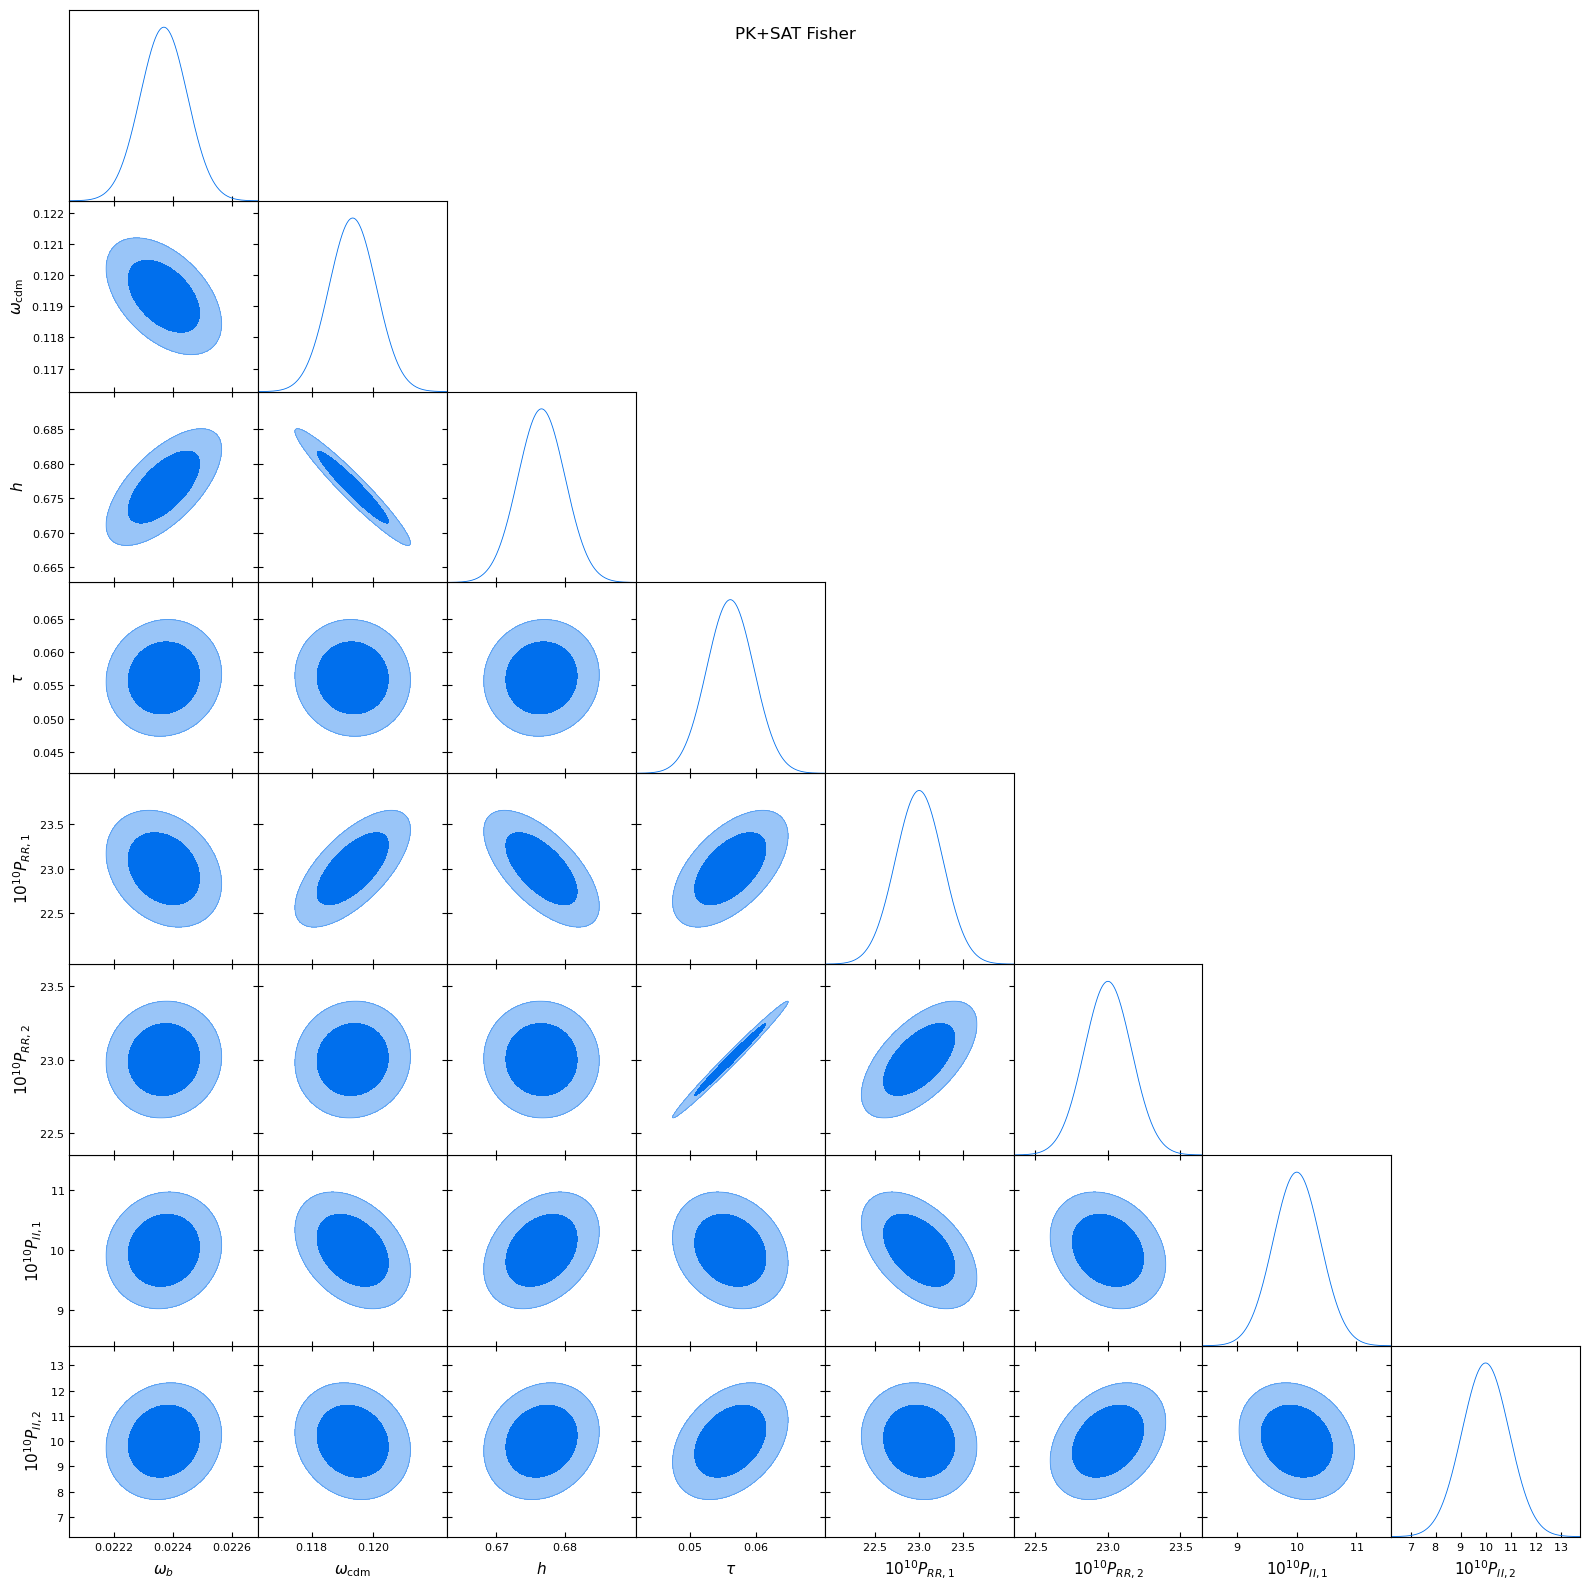

In [155]:
plot_save_suite(result_combined,'PK+SAT')

,Fiducial,sigma,S/N
omega_b,0.02237,0.000872,25.664154
omega_cdm,0.11933,0.011314,10.546810
h,0.67660,0.041442,16.326537
tau_reio,0.05610,0.608211,0.092238
P_RR_1,23.00000,23.958693,0.959986
P_RR_2,23.00000,30.122306,0.763554
P_II_1,10.00000,54.664193,0.182935
P_II_2,10.00000,33.417583,0.299244


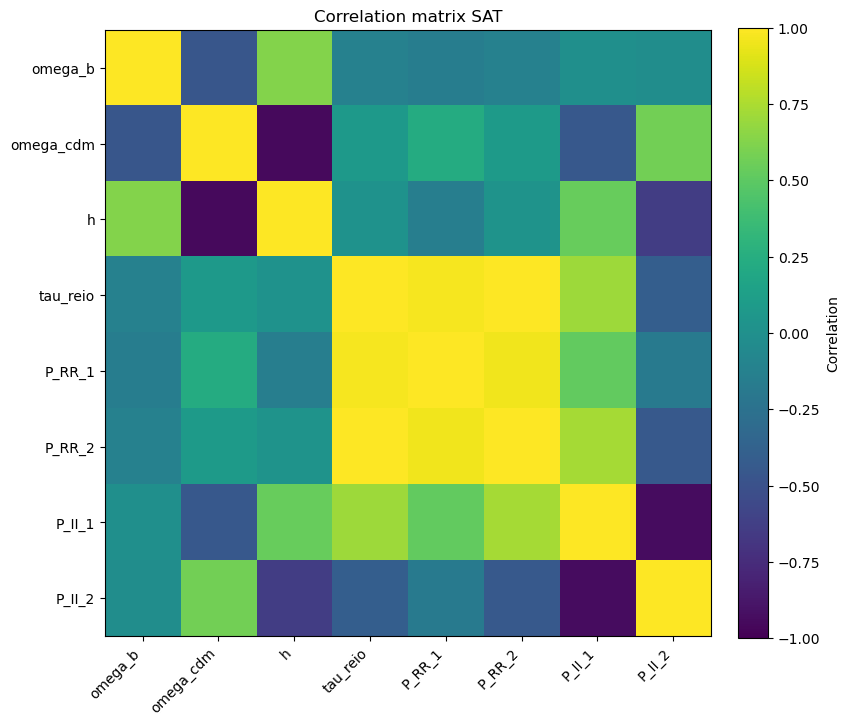

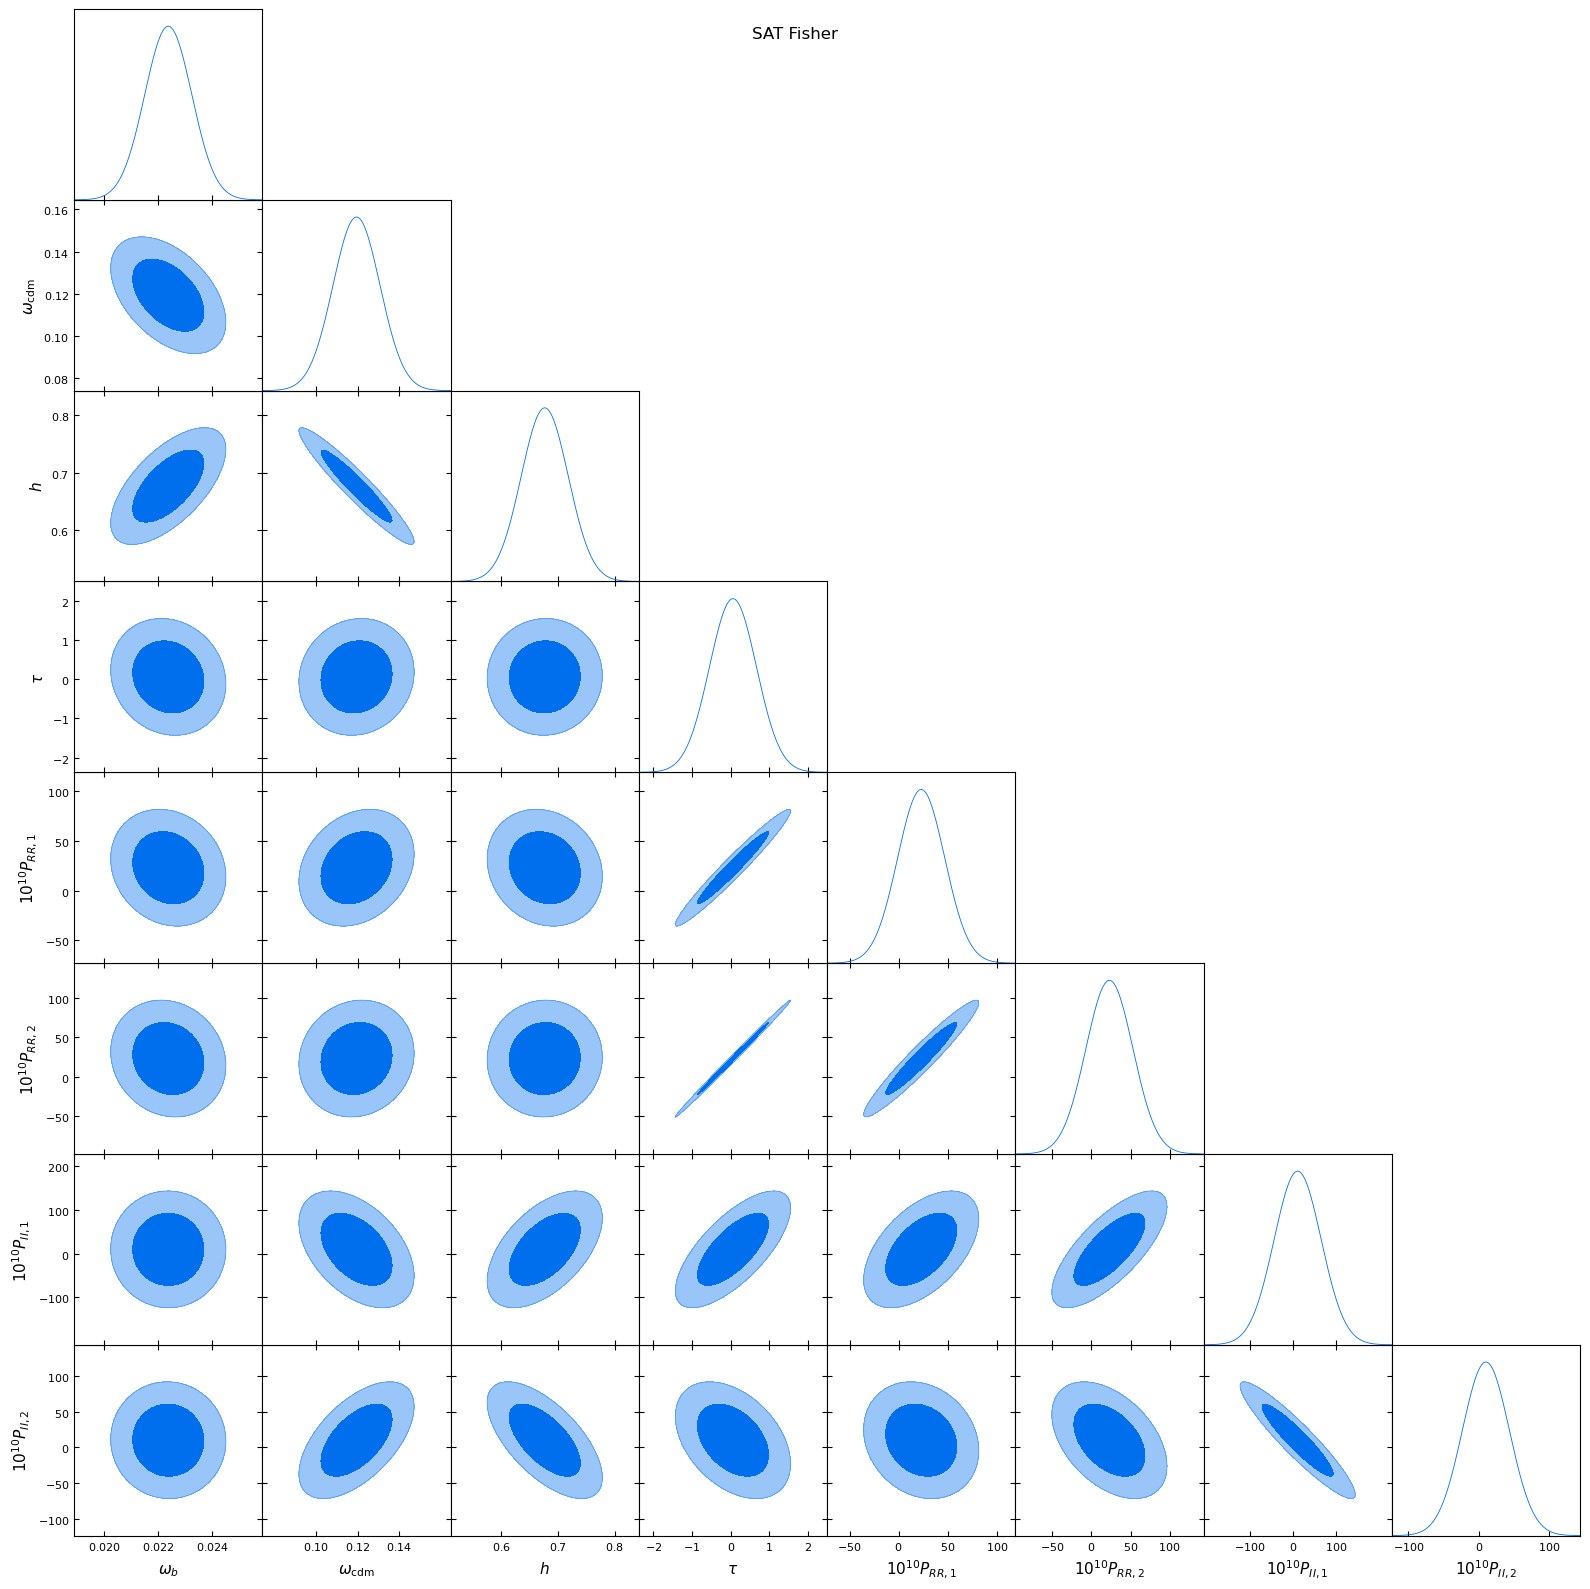

In [156]:
plot_save_suite(result_sat,'SAT')

,Fiducial,sigma,S/N
omega_b,0.02237,3.141115e-08,712167.430423
omega_cdm,0.11933,3.050238e-07,391215.426978
h,0.67660,1.246478e-06,542809.223170
tau_reio,0.05610,5.116370e-06,10964.805833
P_RR_1,23.00000,2.455345e-04,93673.203763
P_RR_2,23.00000,2.310477e-04,99546.545708
P_II_1,10.00000,1.219204e-03,8202.070911
P_II_2,10.00000,9.887086e-04,10114.203243


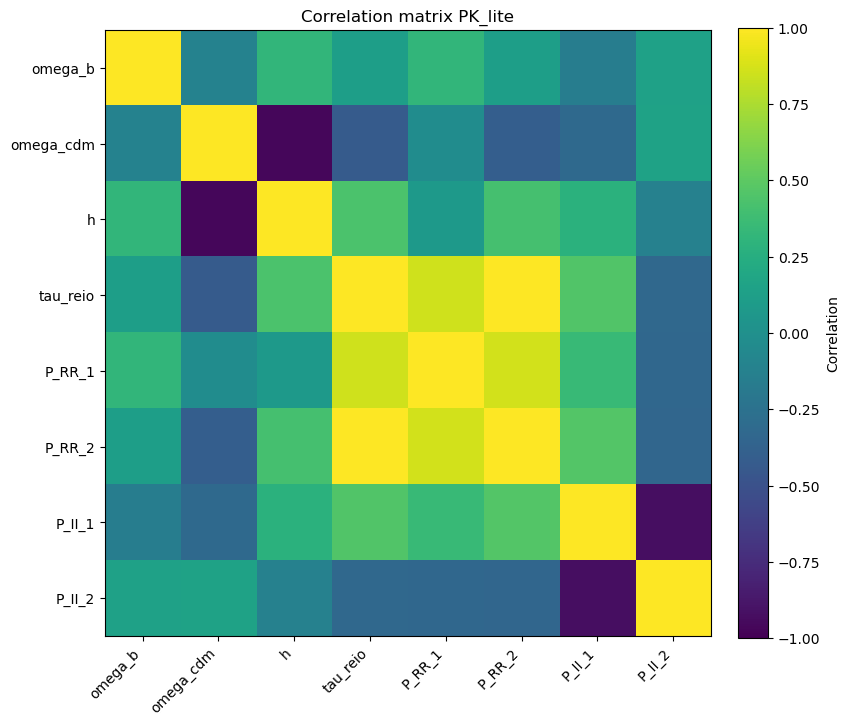

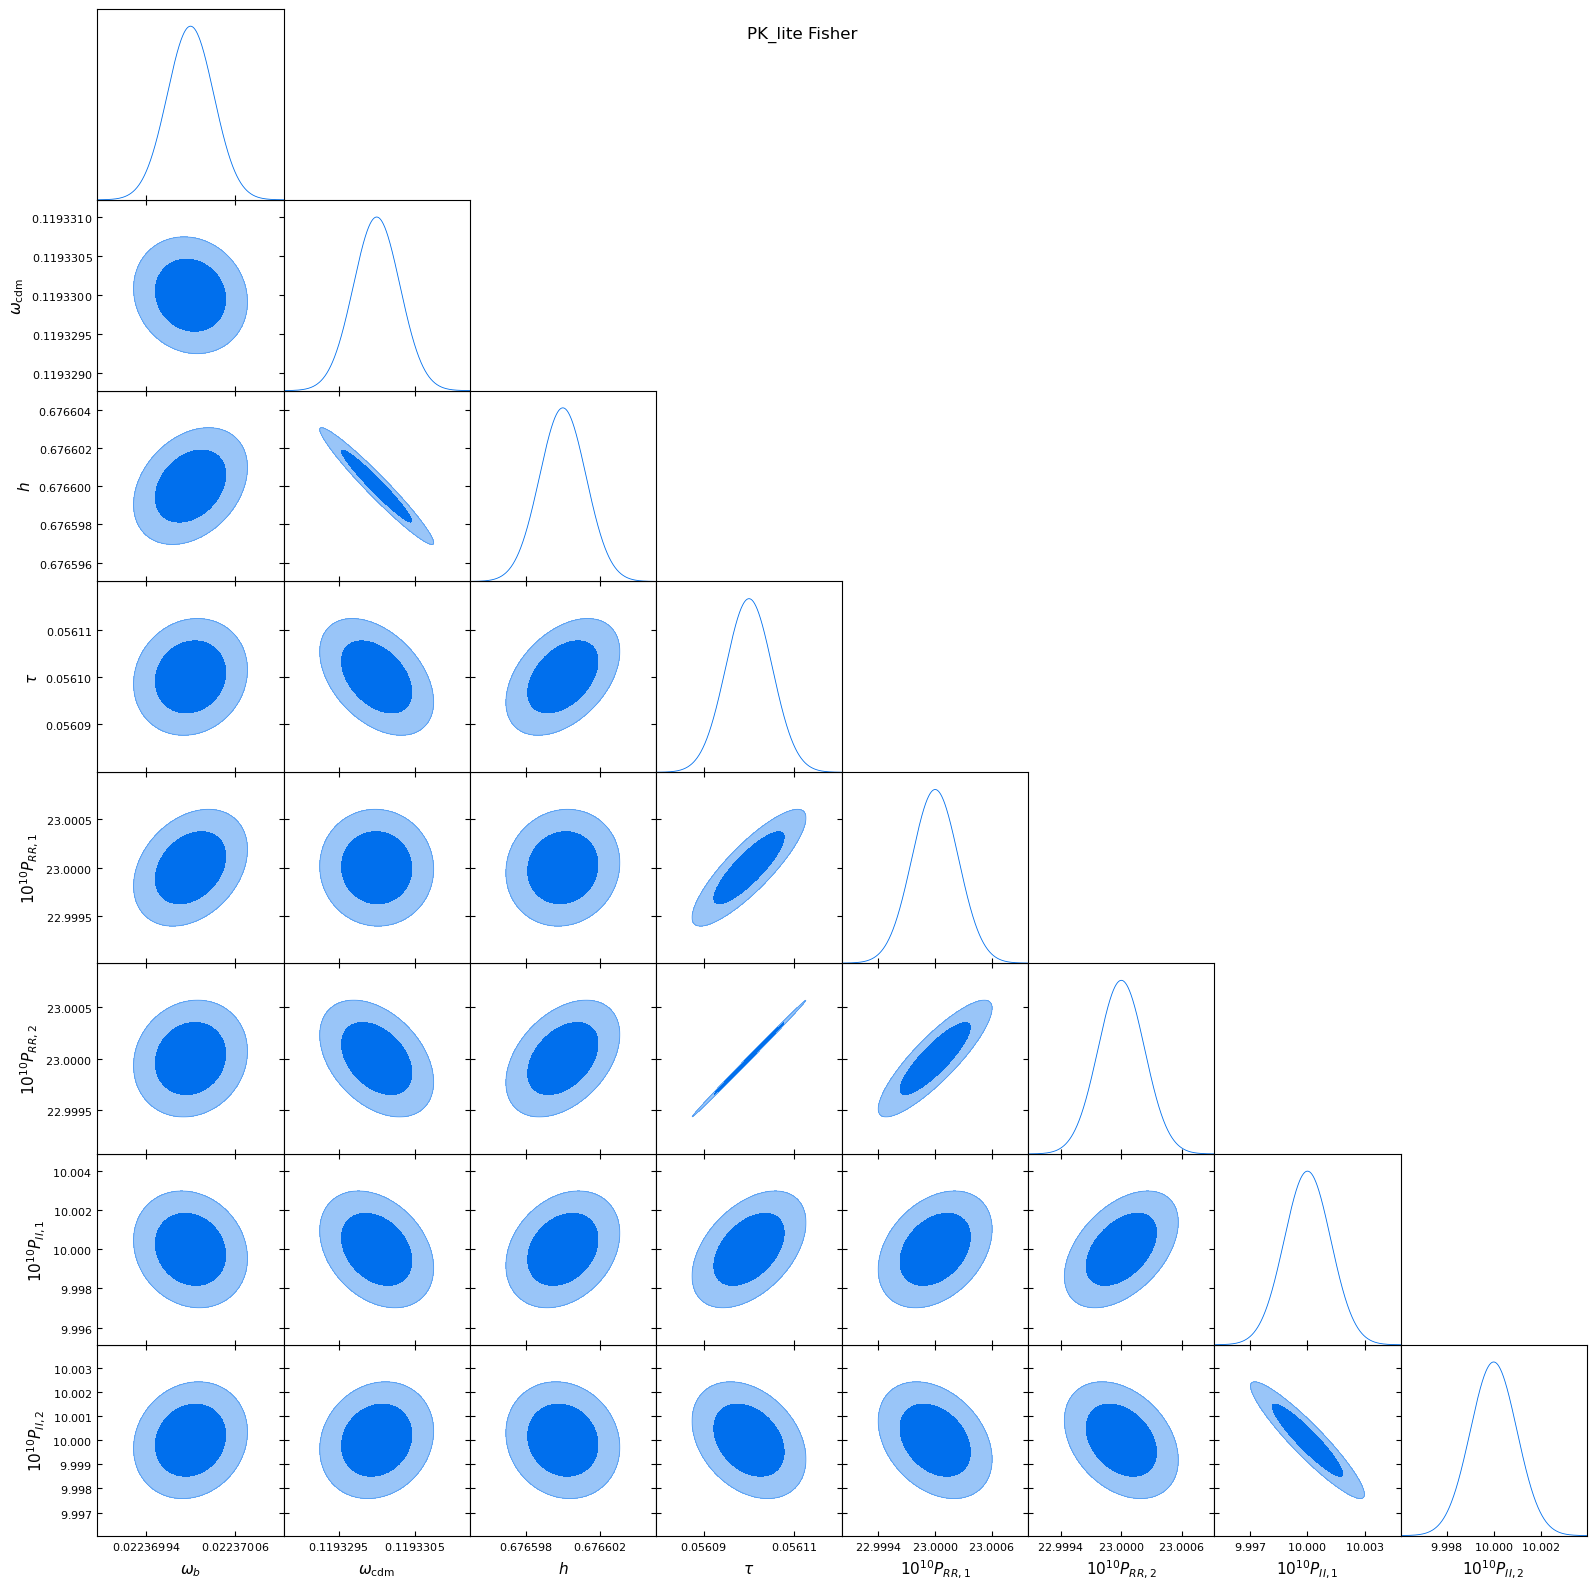

In [157]:
def parse_planck_lite_bands(
    planck_data: dict,
    cell_types:  list[str] = None,
) -> list[SpectrumBand]:
    if cell_types is None:
        cell_types = list(planck_data.keys())

    bands = []
    for cell_type in cell_types:
        d    = planck_data[cell_type]
        ell  = np.asarray(d["ell"],   dtype=float)
        err  = np.asarray(d["err"],   dtype=float)
        bell = np.asarray(d["b_ell"], dtype=float)

        # err and compute_cls are both raw C_ell in µK² — no conversion needed
        bands.append(SpectrumBand(
            exp_key   = "PlanckLite",
            channel   = f"PlanckLite_{cell_type}",
            cell_type = cell_type,
            ell       = ell.astype(int),
            dell      = bell,
            fsky      = 1.0,
            cov       = err**2,
        ))

    return bands
lite_bands = parse_planck_lite_bands(
    lite_data,
    cell_types=["TT", "TE", "EE"],
)

result_lite = fisher_forecast(
    theta0        = theta0,
    param_list    = param_list,
    bands         = lite_bands,
    compute_cls   = compute_cls,
    steps         = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max       = 10_000,
)

plot_save_suite(result_lite, "PK_lite")

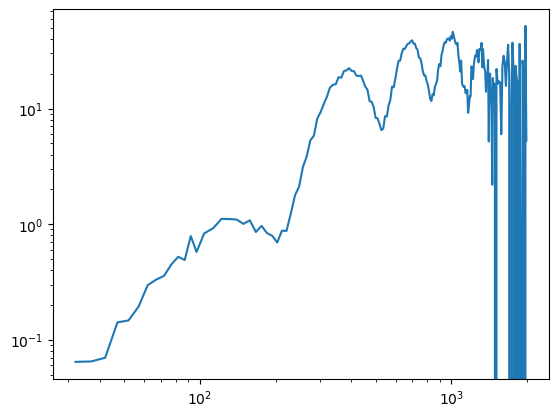

In [158]:
ell_plot = lite_data['EE']['ell']
pfac = ell_plot * (ell_plot + 1)/2/np.pi
plt.errorbar(ell_plot,lite_data['EE']['c_ell']*pfac , yerr = pfac * lite_data['EE']['err'])
plt.xscale('log')
plt.yscale('log')